<a href="https://colab.research.google.com/github/shamimos/Implementaci-n-b-sica-de-una-red-neuronal/blob/main/Evidencia_de_aprendizaje_4_Implementaci%C3%B3n_final_de_red_neuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shara Milena Mosquera Goez
Grupo: PREICA2501B020140

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, Input, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

In [ ]:
# Dimensiones de entrada para las imágene
img_shape = (64, 64, 3) #Las imágenes son de 64x64 píxeles y tienen 3 canales de color
latent_dim = 100

In [ ]:
#Generador
def build_generator():
    model = models.Sequential() # Se crea un modelo secuencial donde las capas se añaden una tras otra
    model.add(layers.Dense(8*8*256, input_dim=latent_dim))  # Capa densa: de vector latente a 8x8x256
    model.add(layers.Reshape((8, 8, 256))) # Reestructura a formato de imagen 8x8 con 256 filtros
    model.add(layers.BatchNormalization()) # Normaliza activaciones
     # Primera capa de convolución transpuesta (deconvolución)
    model.add(layers.Conv2DTranspose(128, 4, strides=2, padding='same', activation='relu')) # Aumenta tamaño a 16x16
    model.add(layers.BatchNormalization())  # normaliza para mantener estable la activación de las neuronas
    # Segunda capa de deconvolución
    model.add(layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu'))  # Aumenta a 32x32
    model.add(layers.BatchNormalization()) # Nueva normalización
    # Capa final de deconvolución
    model.add(layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh'))    # 64x64
    return model  # Retorna el generador completo listo para usar

In [ ]:
# Discriminador
def build_discriminator():
    model = models.Sequential() # Se crea un modelo secuencial, donde las capas se añaden una tras otra en orden.
    model.add(layers.Conv2D(64, 4, strides=2, padding='same', input_shape=img_shape)) #Primera capa convolucional con 64 filtros 4x4, que reduce el tamaño de la imagen a la mitad (64x64 → 32x32) y define el tamaño de entrada como 64x64x3.
    model.add(layers.LeakyReLU(0.2))   # Función de activación LeakyReLU que permite un pequeño gradiente cuando la entrada es negativa.
    model.add(layers.Dropout(0.3))  # Dropout apaga aleatoriamente el 30% de las neuronas durante el entrenamiento. Previene el sobreajuste del modelo.

    model.add(layers.Conv2D(128, 4, strides=2, padding='same')) # Segunda capa convolucional con 128 filtros. Reduce tamaño a 16x16. Aprende características más profundas.
    model.add(layers.LeakyReLU(0.2))  # Se aplica nuevamente LeakyReLU.
    model.add(layers.Dropout(0.3))  # Otro Dropout del 30%.

    model.add(layers.Conv2D(256, 4, strides=2, padding='same'))  # Tercera capa convolucional con 256 filtros. Reduce tamaño a 8x8. Extrae patrones más abstractos de la imagen.
    model.add(layers.LeakyReLU(0.2)) # Activación LeakyReLU para esta capa.
    model.add(layers.Dropout(0.3))  # Tercer Dropout del 30%.

    model.add(layers.Flatten()) # Aplana el volumen tridimensional (8x8x256) en un vector unidimensional. Prepara los datos para la capa densa final.
    model.add(layers.Dense(1, activation='sigmoid'))  # Capa final que devuelve una probabilidad de si la imagen es real o falsa usando activación sigmoide.
    return model

In [ ]:
import os
import requests
from PIL import Image
from io import BytesIO

# Configura tu API Key
API_KEY = 'OfACJPkSZ66ffIDmqRFCCGvVuaGCmq8o4EQXVU2wUpxvklJX4G8ngCIc'
headers = {"Authorization": API_KEY}

# Parámetros de búsqueda
query = "flowers"
num_images = 1000           # Cantidad total de imágenes a descargar
image_size = (64, 64)      # Tamaño al que se redimensionan las imágenes
save_dir = f"Entrenamiento/{query}"
os.makedirs(save_dir, exist_ok=True)

# Lógica de descarga
downloaded = 0
page = 1
per_page = 80  # máximo permitido por Pexels por página

while downloaded < num_images:
    url = f"https://api.pexels.com/v1/search?query={query}&per_page={per_page}&page={page}"
    response = requests.get(url, headers=headers).json()
    if not response.get("photos"):
        break

    for photo in response["photos"]:
        try:
            img_url = photo["src"]["medium"]
            img_data = requests.get(img_url).content
            img = Image.open(BytesIO(img_data)).convert("RGB")
            img = img.resize(image_size)
            img.save(f"{save_dir}/{query}_{downloaded}.jpg")
            print(f"Guardada: {query}_{downloaded}.jpg")
            downloaded += 1
            if downloaded >= num_images:
                break
        except Exception as e:
            print(f"Error con imagen {downloaded}: {e}")
    page += 1



Guardada: flowers_0.jpg
Guardada: flowers_1.jpg
Guardada: flowers_2.jpg
Guardada: flowers_3.jpg
Guardada: flowers_4.jpg
Guardada: flowers_5.jpg
Guardada: flowers_6.jpg
Guardada: flowers_7.jpg
Guardada: flowers_8.jpg
Guardada: flowers_9.jpg
Guardada: flowers_10.jpg
Guardada: flowers_11.jpg
Guardada: flowers_12.jpg
Guardada: flowers_13.jpg
Guardada: flowers_14.jpg
Guardada: flowers_15.jpg
Guardada: flowers_16.jpg
Guardada: flowers_17.jpg
Guardada: flowers_18.jpg
Guardada: flowers_19.jpg
Guardada: flowers_20.jpg
Guardada: flowers_21.jpg
Guardada: flowers_22.jpg
Guardada: flowers_23.jpg
Guardada: flowers_24.jpg
Guardada: flowers_25.jpg
Guardada: flowers_26.jpg
Guardada: flowers_27.jpg
Guardada: flowers_28.jpg
Guardada: flowers_29.jpg
Guardada: flowers_30.jpg
Guardada: flowers_31.jpg
Guardada: flowers_32.jpg
Guardada: flowers_33.jpg
Guardada: flowers_34.jpg
Guardada: flowers_35.jpg
Guardada: flowers_36.jpg
Guardada: flowers_37.jpg
Guardada: flowers_38.jpg
Guardada: flowers_39.jpg
Guardada: 

In [ ]:
data_dir = '/content/Entrenamiento'

datagen = ImageDataGenerator(
    rescale=1./127.5,  # Normaliza los valores de píxeles de [0, 255] a [0, 1]
    horizontal_flip=True,  # Gira aleatoriamente las imágenes horizontalmente (aumenta variedad)
    rotation_range=30, # Rota aleatoriamente las imágenes hasta ±15 grados
    zoom_range=0.2, # Aplica zoom aleatorio hasta un 10%
    preprocessing_function=lambda x: x - 1

)

dataset = datagen.flow_from_directory(
    data_dir, # Ruta donde están las imágenes organizadas en carpetas
    target_size=(64, 64), # Redimensiona todas las imágenes a 64x64 píxeles
    batch_size=32,  # Tamaño del lote: 32 imágenes se cargan por paso
    class_mode=None # No se asignan etiquetas (porque es un GAN, no clasificación)
)

Found 1000 images belonging to 1 classes.


In [ ]:
real_batch = next(dataset) #Obtiene el primer lote de imágenes reales del generador
print("Shape:", real_batch.shape) #Imprime las dimensiones del lote cargado.
print("Mínimo:", np.min(real_batch)) #Imprime el valor mínimo y máximo de los píxeles en las imágenes del lote.
print("Máximo:", np.max(real_batch))

Shape: (32, 64, 64, 3)
Mínimo: -0.007843138
Máximo: 1.992157


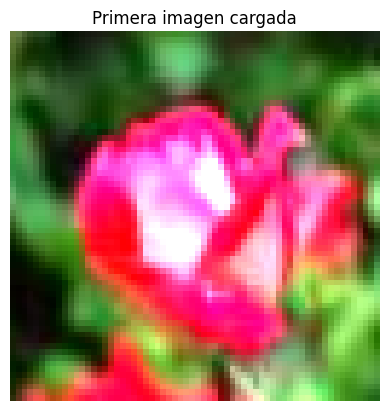

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(real_batch[0]) #Muestra la primera imagen del lote
plt.axis('off')
plt.title("Primera imagen cargada")
plt.show()

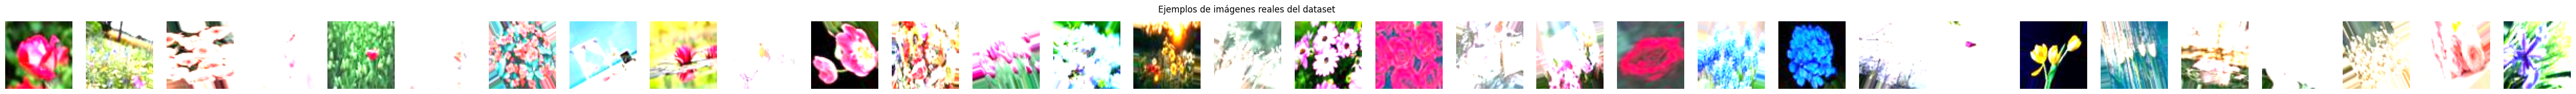

In [ ]:
num_imgs = real_batch.shape[0] #Obtiene la cantidad de imágenes en el lote cargado

plt.figure(figsize=(num_imgs * 2, 2))
for i in range(num_imgs):
    plt.subplot(1, num_imgs, i + 1)
    plt.imshow(real_batch[i])
    plt.axis('off')
plt.suptitle("Ejemplos de imágenes reales del dataset")
plt.show()


In [ ]:
# Compilación
discriminator = build_discriminator()
# Compila el discriminador con función de pérdida binaria y optimizador Adam
discriminator.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(0.0002, 0.5), metrics=['accuracy'])

generator = build_generator() # Construye el modelo generador

discriminator.trainable = False # Se congela el discriminador para que no se entrene dentro del modelo GAN
gan_input = Input(shape=(latent_dim,)) # Entrada del modelo GAN: vector de ruido (latent space)
generated_img = generator(gan_input) # El generador convierte el vector de ruido en una imagen falsa
gan_output = discriminator(generated_img) ## El discriminador evalúa la imagen generada y da una probabilidad de que sea real
gan = models.Model(gan_input, gan_output) # Se crea el modelo completo GAN: ruido → generador → discriminador
gan.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(0.0002, 0.5)) # Compila la GAN (solo entrena el generador, el discriminador está congelado)

In [ ]:
def generate_and_save_images(generator, epoch, n=5):
    noise = np.random.normal(0, 1, (n, latent_dim)) # Genera un lote de vectores de ruido aleatorios con distribución normal
    gen_imgs = generator.predict(noise, verbose=0)  # Usa el generador para crear imágenes a partir del ruido
    gen_imgs = 0.5 * gen_imgs + 0.5   # Desnormaliza las imágenes de [-1, 1] a [0, 1] para poder visualizarlas correctamente

    plt.figure(figsize=(15, 3)) # Crea una figura con tamaño proporcional al número de imágenes
     # Muestra cada imagen generada en una subgráfica
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(gen_imgs[i])
        plt.axis('off')
    plt.suptitle(f'Imágenes generadas - Epoch {epoch}')
    plt.show()

0 [D loss: 0.6922, acc: 59.38%] [G loss: 0.7069]


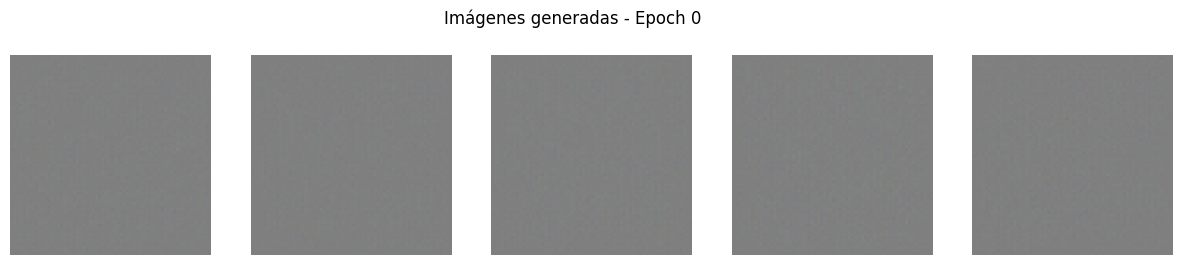

1 [D loss: 0.6847, acc: 67.19%] [G loss: 0.7063]
2 [D loss: 0.6867, acc: 64.27%] [G loss: 0.7034]
3 [D loss: 0.6875, acc: 61.36%] [G loss: 0.7010]
4 [D loss: 0.6868, acc: 58.42%] [G loss: 0.6995]
5 [D loss: 0.6875, acc: 54.56%] [G loss: 0.6973]
6 [D loss: 0.6891, acc: 51.54%] [G loss: 0.6922]
7 [D loss: 0.6887, acc: 49.94%] [G loss: 0.6879]
8 [D loss: 0.6887, acc: 48.06%] [G loss: 0.6843]
9 [D loss: 0.6883, acc: 47.30%] [G loss: 0.6815]
10 [D loss: 0.6887, acc: 46.31%] [G loss: 0.6779]
11 [D loss: 0.6887, acc: 45.36%] [G loss: 0.6751]
12 [D loss: 0.6888, acc: 44.25%] [G loss: 0.6719]
13 [D loss: 0.6894, acc: 42.97%] [G loss: 0.6692]
14 [D loss: 0.6905, acc: 41.64%] [G loss: 0.6663]
15 [D loss: 0.6905, acc: 40.68%] [G loss: 0.6632]
16 [D loss: 0.6906, acc: 39.61%] [G loss: 0.6604]
17 [D loss: 0.6903, acc: 39.49%] [G loss: 0.6579]
18 [D loss: 0.6905, acc: 38.76%] [G loss: 0.6551]
19 [D loss: 0.6910, acc: 38.14%] [G loss: 0.6517]
20 [D loss: 0.6914, acc: 37.39%] [G loss: 0.6484]
21 [D los

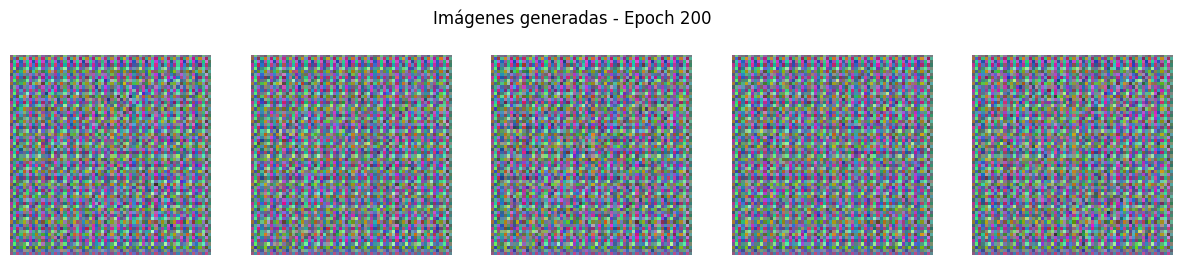

201 [D loss: 0.7306, acc: 28.80%] [G loss: 0.2995]
202 [D loss: 0.7312, acc: 28.78%] [G loss: 0.2984]
203 [D loss: 0.7319, acc: 28.75%] [G loss: 0.2974]
204 [D loss: 0.7325, acc: 28.74%] [G loss: 0.2963]
205 [D loss: 0.7331, acc: 28.76%] [G loss: 0.2953]
206 [D loss: 0.7338, acc: 28.76%] [G loss: 0.2943]
207 [D loss: 0.7344, acc: 28.74%] [G loss: 0.2933]
208 [D loss: 0.7351, acc: 28.74%] [G loss: 0.2923]
209 [D loss: 0.7359, acc: 28.71%] [G loss: 0.2913]
210 [D loss: 0.7366, acc: 28.65%] [G loss: 0.2903]
211 [D loss: 0.7373, acc: 28.66%] [G loss: 0.2893]
212 [D loss: 0.7380, acc: 28.65%] [G loss: 0.2883]
213 [D loss: 0.7387, acc: 28.64%] [G loss: 0.2873]
214 [D loss: 0.7395, acc: 28.60%] [G loss: 0.2863]
215 [D loss: 0.7403, acc: 28.61%] [G loss: 0.2854]
216 [D loss: 0.7410, acc: 28.62%] [G loss: 0.2844]
217 [D loss: 0.7417, acc: 28.61%] [G loss: 0.2834]
218 [D loss: 0.7425, acc: 28.57%] [G loss: 0.2825]
219 [D loss: 0.7433, acc: 28.56%] [G loss: 0.2815]
220 [D loss: 0.7440, acc: 28.56

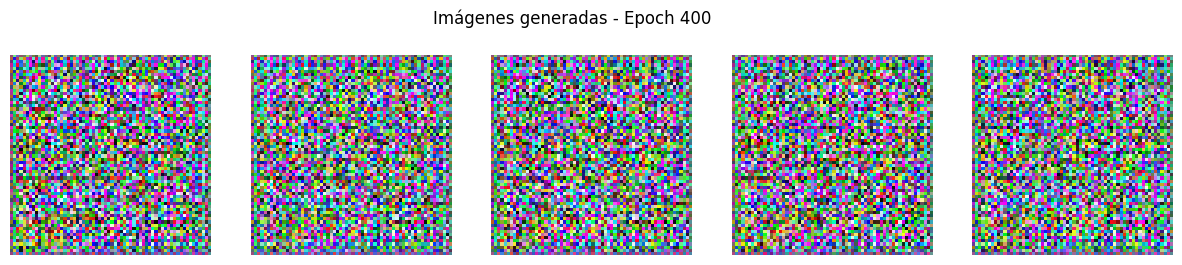

401 [D loss: 1.0240, acc: 27.68%] [G loss: 0.1743]
402 [D loss: 1.0261, acc: 27.68%] [G loss: 0.1739]
403 [D loss: 1.0282, acc: 27.69%] [G loss: 0.1736]
404 [D loss: 1.0304, acc: 27.68%] [G loss: 0.1732]
405 [D loss: 1.0325, acc: 27.71%] [G loss: 0.1728]
406 [D loss: 1.0346, acc: 27.71%] [G loss: 0.1725]
407 [D loss: 1.0368, acc: 27.72%] [G loss: 0.1721]
408 [D loss: 1.0390, acc: 27.69%] [G loss: 0.1718]
409 [D loss: 1.0411, acc: 27.68%] [G loss: 0.1714]
410 [D loss: 1.0433, acc: 27.70%] [G loss: 0.1711]
411 [D loss: 1.0455, acc: 27.70%] [G loss: 0.1707]
412 [D loss: 1.0476, acc: 27.71%] [G loss: 0.1704]
413 [D loss: 1.0498, acc: 27.71%] [G loss: 0.1700]
414 [D loss: 1.0514, acc: 27.70%] [G loss: 0.1697]
415 [D loss: 1.0526, acc: 27.71%] [G loss: 0.1693]
416 [D loss: 1.0548, acc: 27.69%] [G loss: 0.1690]
417 [D loss: 1.0569, acc: 27.69%] [G loss: 0.1686]
418 [D loss: 1.0591, acc: 27.69%] [G loss: 0.1683]
419 [D loss: 1.0613, acc: 27.68%] [G loss: 0.1680]
420 [D loss: 1.0634, acc: 27.67

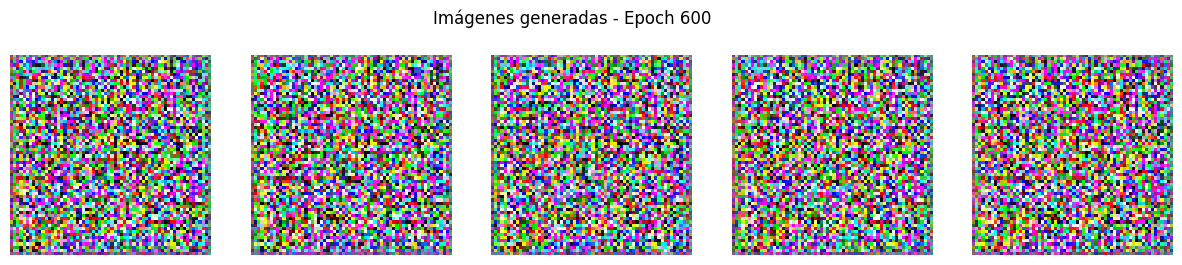

601 [D loss: 1.4179, acc: 27.38%] [G loss: 0.1231]
602 [D loss: 1.4197, acc: 27.38%] [G loss: 0.1229]
603 [D loss: 1.4214, acc: 27.39%] [G loss: 0.1227]
604 [D loss: 1.4232, acc: 27.38%] [G loss: 0.1225]
605 [D loss: 1.4249, acc: 27.38%] [G loss: 0.1224]
606 [D loss: 1.4262, acc: 27.37%] [G loss: 0.1222]
607 [D loss: 1.4270, acc: 27.37%] [G loss: 0.1220]
608 [D loss: 1.4287, acc: 27.37%] [G loss: 0.1218]
609 [D loss: 1.4304, acc: 27.36%] [G loss: 0.1217]
610 [D loss: 1.4321, acc: 27.36%] [G loss: 0.1215]
611 [D loss: 1.4338, acc: 27.36%] [G loss: 0.1213]
612 [D loss: 1.4355, acc: 27.36%] [G loss: 0.1211]
613 [D loss: 1.4373, acc: 27.36%] [G loss: 0.1210]
614 [D loss: 1.4390, acc: 27.36%] [G loss: 0.1208]
615 [D loss: 1.4407, acc: 27.36%] [G loss: 0.1206]
616 [D loss: 1.4423, acc: 27.35%] [G loss: 0.1204]
617 [D loss: 1.4440, acc: 27.35%] [G loss: 0.1203]
618 [D loss: 1.4457, acc: 27.36%] [G loss: 0.1201]
619 [D loss: 1.4474, acc: 27.36%] [G loss: 0.1199]
620 [D loss: 1.4490, acc: 27.37

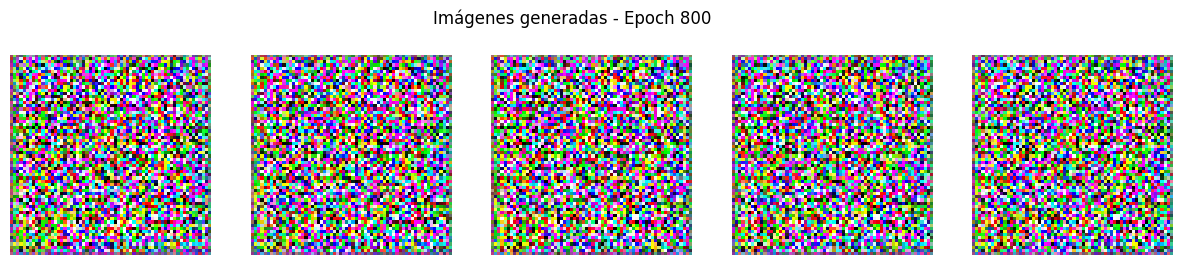

801 [D loss: 1.7016, acc: 27.20%] [G loss: 0.0954]
802 [D loss: 1.7028, acc: 27.21%] [G loss: 0.0953]
803 [D loss: 1.7040, acc: 27.22%] [G loss: 0.0952]
804 [D loss: 1.7052, acc: 27.22%] [G loss: 0.0951]
805 [D loss: 1.7064, acc: 27.22%] [G loss: 0.0950]
806 [D loss: 1.7076, acc: 27.22%] [G loss: 0.0949]
807 [D loss: 1.7089, acc: 27.22%] [G loss: 0.0948]
808 [D loss: 1.7101, acc: 27.23%] [G loss: 0.0947]
809 [D loss: 1.7112, acc: 27.23%] [G loss: 0.0946]
810 [D loss: 1.7125, acc: 27.22%] [G loss: 0.0945]
811 [D loss: 1.7137, acc: 27.22%] [G loss: 0.0944]
812 [D loss: 1.7149, acc: 27.22%] [G loss: 0.0943]
813 [D loss: 1.7161, acc: 27.22%] [G loss: 0.0942]
814 [D loss: 1.7173, acc: 27.21%] [G loss: 0.0941]
815 [D loss: 1.7185, acc: 27.21%] [G loss: 0.0940]
816 [D loss: 1.7197, acc: 27.20%] [G loss: 0.0939]
817 [D loss: 1.7209, acc: 27.21%] [G loss: 0.0938]
818 [D loss: 1.7220, acc: 27.21%] [G loss: 0.0937]
819 [D loss: 1.7232, acc: 27.21%] [G loss: 0.0936]
820 [D loss: 1.7244, acc: 27.20

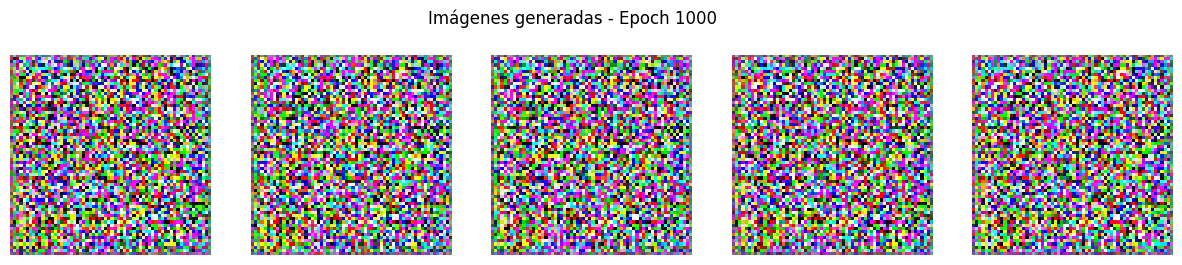

1001 [D loss: 1.9073, acc: 27.10%] [G loss: 0.0781]
1002 [D loss: 1.9083, acc: 27.10%] [G loss: 0.0781]
1003 [D loss: 1.9092, acc: 27.10%] [G loss: 0.0780]
1004 [D loss: 1.9101, acc: 27.10%] [G loss: 0.0779]
1005 [D loss: 1.9110, acc: 27.09%] [G loss: 0.0779]
1006 [D loss: 1.9119, acc: 27.09%] [G loss: 0.0778]
1007 [D loss: 1.9128, acc: 27.09%] [G loss: 0.0777]
1008 [D loss: 1.9137, acc: 27.09%] [G loss: 0.0777]
1009 [D loss: 1.9146, acc: 27.09%] [G loss: 0.0776]
1010 [D loss: 1.9155, acc: 27.09%] [G loss: 0.0775]
1011 [D loss: 1.9164, acc: 27.09%] [G loss: 0.0774]
1012 [D loss: 1.9173, acc: 27.09%] [G loss: 0.0774]
1013 [D loss: 1.9181, acc: 27.09%] [G loss: 0.0773]
1014 [D loss: 1.9190, acc: 27.09%] [G loss: 0.0772]
1015 [D loss: 1.9199, acc: 27.08%] [G loss: 0.0772]
1016 [D loss: 1.9208, acc: 27.09%] [G loss: 0.0771]
1017 [D loss: 1.9217, acc: 27.08%] [G loss: 0.0770]
1018 [D loss: 1.9226, acc: 27.09%] [G loss: 0.0770]
1019 [D loss: 1.9235, acc: 27.08%] [G loss: 0.0769]
1020 [D loss

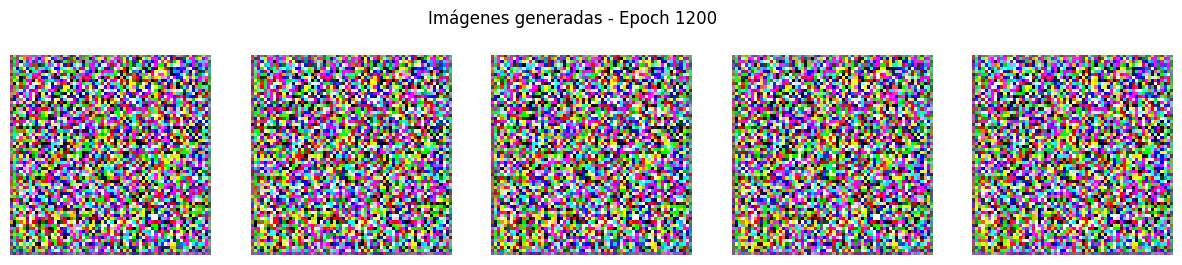

1201 [D loss: 2.0654, acc: 26.98%] [G loss: 0.0663]
1202 [D loss: 2.0661, acc: 26.98%] [G loss: 0.0662]
1203 [D loss: 2.0668, acc: 26.98%] [G loss: 0.0662]
1204 [D loss: 2.0675, acc: 26.98%] [G loss: 0.0661]
1205 [D loss: 2.0682, acc: 26.98%] [G loss: 0.0661]
1206 [D loss: 2.0690, acc: 26.98%] [G loss: 0.0660]
1207 [D loss: 2.0697, acc: 26.98%] [G loss: 0.0660]
1208 [D loss: 2.0704, acc: 26.97%] [G loss: 0.0659]
1209 [D loss: 2.0711, acc: 26.97%] [G loss: 0.0659]
1210 [D loss: 2.0718, acc: 26.97%] [G loss: 0.0658]
1211 [D loss: 2.0726, acc: 26.97%] [G loss: 0.0658]
1212 [D loss: 2.0733, acc: 26.96%] [G loss: 0.0657]
1213 [D loss: 2.0740, acc: 26.96%] [G loss: 0.0657]
1214 [D loss: 2.0746, acc: 26.96%] [G loss: 0.0656]
1215 [D loss: 2.0749, acc: 26.96%] [G loss: 0.0656]
1216 [D loss: 2.0756, acc: 26.96%] [G loss: 0.0655]
1217 [D loss: 2.0763, acc: 26.97%] [G loss: 0.0655]
1218 [D loss: 2.0770, acc: 26.97%] [G loss: 0.0654]
1219 [D loss: 2.0777, acc: 26.96%] [G loss: 0.0654]
1220 [D loss

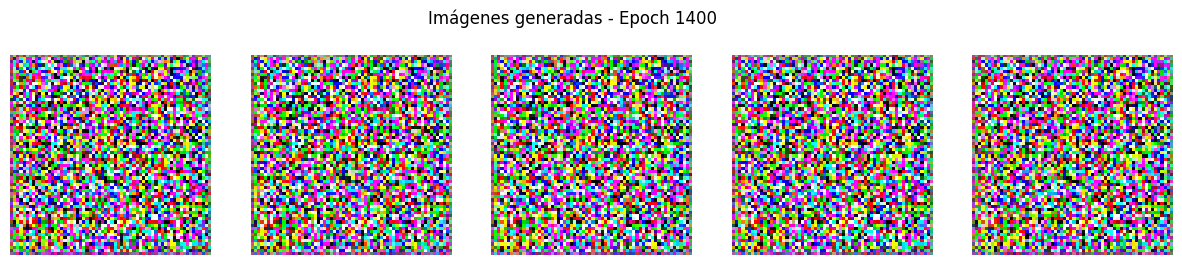

1401 [D loss: 2.1924, acc: 26.86%] [G loss: 0.0576]
1402 [D loss: 2.1930, acc: 26.86%] [G loss: 0.0576]
1403 [D loss: 2.1936, acc: 26.86%] [G loss: 0.0575]
1404 [D loss: 2.1942, acc: 26.87%] [G loss: 0.0575]
1405 [D loss: 2.1948, acc: 26.87%] [G loss: 0.0575]
1406 [D loss: 2.1954, acc: 26.86%] [G loss: 0.0574]
1407 [D loss: 2.1955, acc: 26.86%] [G loss: 0.0574]
1408 [D loss: 2.1961, acc: 26.86%] [G loss: 0.0573]
1409 [D loss: 2.1967, acc: 26.86%] [G loss: 0.0573]
1410 [D loss: 2.1973, acc: 26.86%] [G loss: 0.0573]
1411 [D loss: 2.1979, acc: 26.86%] [G loss: 0.0572]
1412 [D loss: 2.1985, acc: 26.86%] [G loss: 0.0572]
1413 [D loss: 2.1991, acc: 26.86%] [G loss: 0.0572]
1414 [D loss: 2.1996, acc: 26.87%] [G loss: 0.0571]
1415 [D loss: 2.2002, acc: 26.87%] [G loss: 0.0571]
1416 [D loss: 2.2008, acc: 26.87%] [G loss: 0.0571]
1417 [D loss: 2.2014, acc: 26.87%] [G loss: 0.0570]
1418 [D loss: 2.2020, acc: 26.87%] [G loss: 0.0570]
1419 [D loss: 2.2026, acc: 26.87%] [G loss: 0.0569]
1420 [D loss

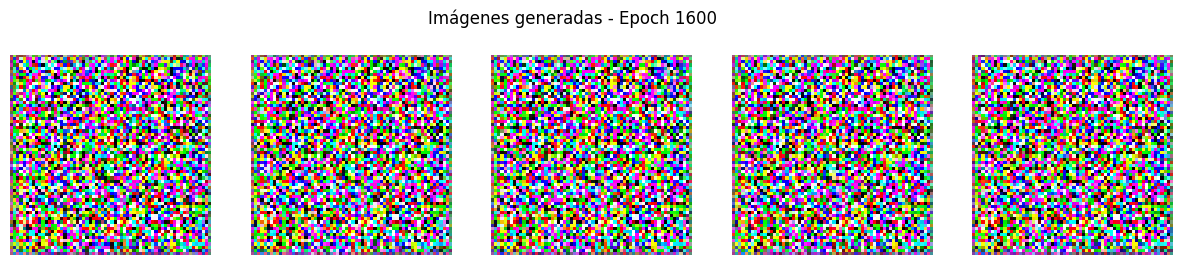

1601 [D loss: 2.2976, acc: 26.80%] [G loss: 0.0510]
1602 [D loss: 2.2981, acc: 26.80%] [G loss: 0.0510]
1603 [D loss: 2.2986, acc: 26.80%] [G loss: 0.0509]
1604 [D loss: 2.2991, acc: 26.80%] [G loss: 0.0509]
1605 [D loss: 2.2996, acc: 26.80%] [G loss: 0.0509]
1606 [D loss: 2.3001, acc: 26.79%] [G loss: 0.0509]
1607 [D loss: 2.3006, acc: 26.79%] [G loss: 0.0508]
1608 [D loss: 2.3011, acc: 26.79%] [G loss: 0.0508]
1609 [D loss: 2.3016, acc: 26.79%] [G loss: 0.0508]
1610 [D loss: 2.3021, acc: 26.79%] [G loss: 0.0507]
1611 [D loss: 2.3026, acc: 26.79%] [G loss: 0.0507]
1612 [D loss: 2.3031, acc: 26.79%] [G loss: 0.0507]
1613 [D loss: 2.3036, acc: 26.80%] [G loss: 0.0507]
1614 [D loss: 2.3041, acc: 26.80%] [G loss: 0.0506]
1615 [D loss: 2.3045, acc: 26.79%] [G loss: 0.0506]
1616 [D loss: 2.3050, acc: 26.80%] [G loss: 0.0506]
1617 [D loss: 2.3055, acc: 26.80%] [G loss: 0.0505]
1618 [D loss: 2.3060, acc: 26.80%] [G loss: 0.0505]
1619 [D loss: 2.3065, acc: 26.80%] [G loss: 0.0505]
1620 [D loss

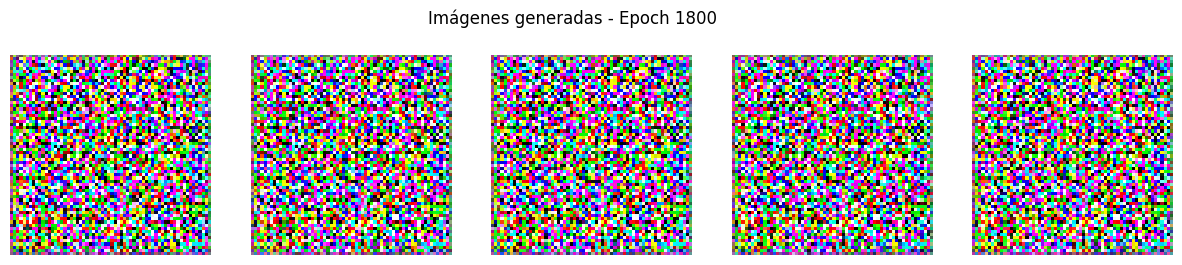

1801 [D loss: 2.3870, acc: 26.78%] [G loss: 0.0458]
1802 [D loss: 2.3874, acc: 26.78%] [G loss: 0.0458]
1803 [D loss: 2.3879, acc: 26.78%] [G loss: 0.0458]
1804 [D loss: 2.3883, acc: 26.79%] [G loss: 0.0457]
1805 [D loss: 2.3887, acc: 26.79%] [G loss: 0.0457]
1806 [D loss: 2.3891, acc: 26.79%] [G loss: 0.0457]
1807 [D loss: 2.3895, acc: 26.79%] [G loss: 0.0457]
1808 [D loss: 2.3900, acc: 26.79%] [G loss: 0.0456]
1809 [D loss: 2.3904, acc: 26.79%] [G loss: 0.0456]
1810 [D loss: 2.3908, acc: 26.79%] [G loss: 0.0456]
1811 [D loss: 2.3912, acc: 26.79%] [G loss: 0.0456]
1812 [D loss: 2.3916, acc: 26.79%] [G loss: 0.0455]
1813 [D loss: 2.3920, acc: 26.78%] [G loss: 0.0455]
1814 [D loss: 2.3925, acc: 26.79%] [G loss: 0.0455]
1815 [D loss: 2.3929, acc: 26.79%] [G loss: 0.0455]
1816 [D loss: 2.3933, acc: 26.78%] [G loss: 0.0455]
1817 [D loss: 2.3937, acc: 26.78%] [G loss: 0.0454]
1818 [D loss: 2.3942, acc: 26.78%] [G loss: 0.0454]
1819 [D loss: 2.3946, acc: 26.78%] [G loss: 0.0454]
1820 [D loss

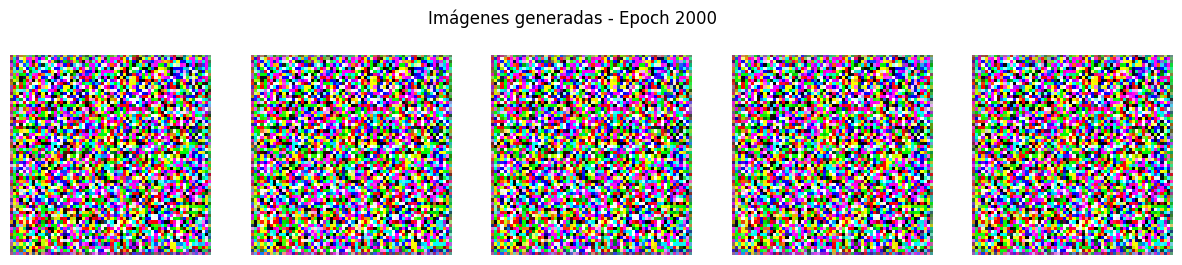

2001 [D loss: 2.4640, acc: 26.78%] [G loss: 0.0416]
2002 [D loss: 2.4644, acc: 26.77%] [G loss: 0.0416]
2003 [D loss: 2.4648, acc: 26.77%] [G loss: 0.0416]
2004 [D loss: 2.4651, acc: 26.77%] [G loss: 0.0415]
2005 [D loss: 2.4655, acc: 26.77%] [G loss: 0.0415]
2006 [D loss: 2.4659, acc: 26.77%] [G loss: 0.0415]
2007 [D loss: 2.4663, acc: 26.77%] [G loss: 0.0415]
2008 [D loss: 2.4666, acc: 26.77%] [G loss: 0.0415]
2009 [D loss: 2.4670, acc: 26.77%] [G loss: 0.0414]
2010 [D loss: 2.4673, acc: 26.77%] [G loss: 0.0414]
2011 [D loss: 2.4677, acc: 26.77%] [G loss: 0.0414]
2012 [D loss: 2.4681, acc: 26.77%] [G loss: 0.0414]
2013 [D loss: 2.4684, acc: 26.76%] [G loss: 0.0414]
2014 [D loss: 2.4688, acc: 26.76%] [G loss: 0.0414]
2015 [D loss: 2.4689, acc: 26.77%] [G loss: 0.0413]
2016 [D loss: 2.4693, acc: 26.77%] [G loss: 0.0413]
2017 [D loss: 2.4696, acc: 26.76%] [G loss: 0.0413]
2018 [D loss: 2.4700, acc: 26.76%] [G loss: 0.0413]
2019 [D loss: 2.4704, acc: 26.76%] [G loss: 0.0413]
2020 [D loss

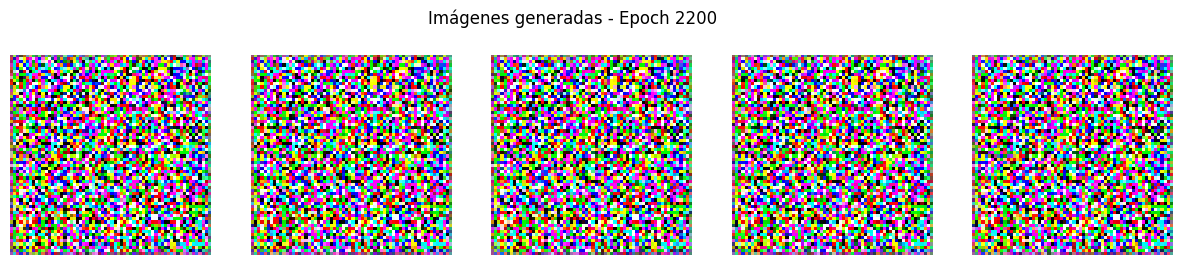

2201 [D loss: 2.5314, acc: 26.75%] [G loss: 0.0381]
2202 [D loss: 2.5317, acc: 26.75%] [G loss: 0.0381]
2203 [D loss: 2.5320, acc: 26.75%] [G loss: 0.0381]
2204 [D loss: 2.5323, acc: 26.75%] [G loss: 0.0381]
2205 [D loss: 2.5327, acc: 26.75%] [G loss: 0.0381]
2206 [D loss: 2.5330, acc: 26.75%] [G loss: 0.0380]
2207 [D loss: 2.5331, acc: 26.75%] [G loss: 0.0380]
2208 [D loss: 2.5334, acc: 26.75%] [G loss: 0.0380]
2209 [D loss: 2.5337, acc: 26.75%] [G loss: 0.0380]
2210 [D loss: 2.5340, acc: 26.75%] [G loss: 0.0380]
2211 [D loss: 2.5344, acc: 26.75%] [G loss: 0.0380]
2212 [D loss: 2.5347, acc: 26.75%] [G loss: 0.0380]
2213 [D loss: 2.5350, acc: 26.75%] [G loss: 0.0379]
2214 [D loss: 2.5353, acc: 26.75%] [G loss: 0.0379]
2215 [D loss: 2.5356, acc: 26.75%] [G loss: 0.0379]
2216 [D loss: 2.5360, acc: 26.75%] [G loss: 0.0379]
2217 [D loss: 2.5363, acc: 26.76%] [G loss: 0.0379]
2218 [D loss: 2.5366, acc: 26.76%] [G loss: 0.0379]
2219 [D loss: 2.5369, acc: 26.76%] [G loss: 0.0378]
2220 [D loss

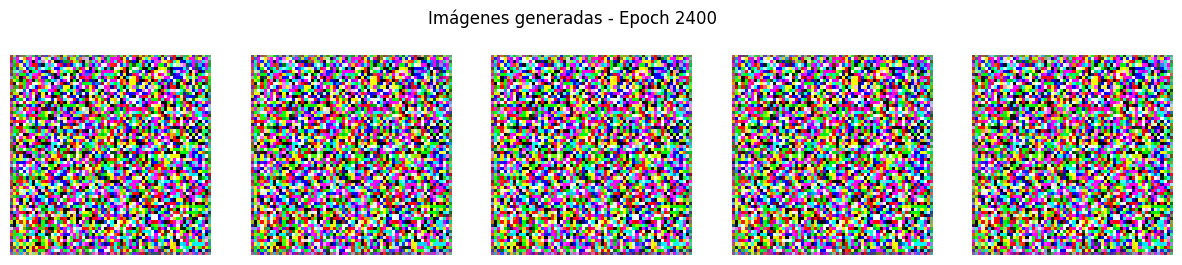

2401 [D loss: 2.5908, acc: 26.72%] [G loss: 0.0352]
2402 [D loss: 2.5911, acc: 26.72%] [G loss: 0.0352]
2403 [D loss: 2.5914, acc: 26.73%] [G loss: 0.0352]
2404 [D loss: 2.5917, acc: 26.73%] [G loss: 0.0352]
2405 [D loss: 2.5920, acc: 26.72%] [G loss: 0.0352]
2406 [D loss: 2.5922, acc: 26.72%] [G loss: 0.0351]
2407 [D loss: 2.5925, acc: 26.72%] [G loss: 0.0351]
2408 [D loss: 2.5928, acc: 26.72%] [G loss: 0.0351]
2409 [D loss: 2.5931, acc: 26.72%] [G loss: 0.0351]
2410 [D loss: 2.5934, acc: 26.72%] [G loss: 0.0351]
2411 [D loss: 2.5937, acc: 26.72%] [G loss: 0.0351]
2412 [D loss: 2.5940, acc: 26.72%] [G loss: 0.0351]
2413 [D loss: 2.5943, acc: 26.72%] [G loss: 0.0350]
2414 [D loss: 2.5945, acc: 26.72%] [G loss: 0.0350]
2415 [D loss: 2.5948, acc: 26.72%] [G loss: 0.0350]
2416 [D loss: 2.5951, acc: 26.72%] [G loss: 0.0350]
2417 [D loss: 2.5954, acc: 26.72%] [G loss: 0.0350]
2418 [D loss: 2.5957, acc: 26.72%] [G loss: 0.0350]
2419 [D loss: 2.5960, acc: 26.72%] [G loss: 0.0350]
2420 [D loss

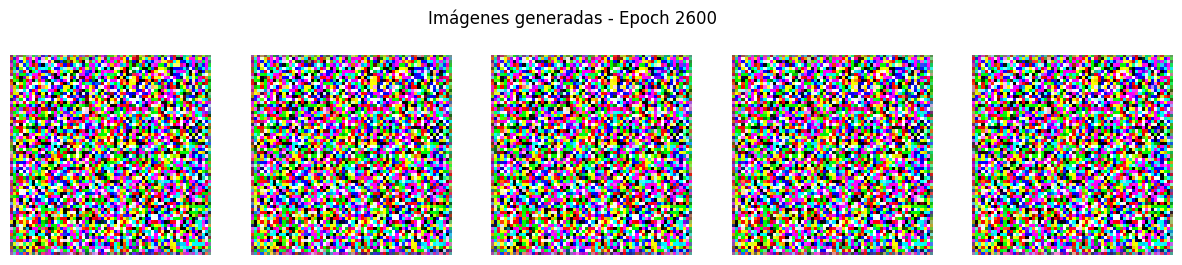

2601 [D loss: 2.6439, acc: 26.72%] [G loss: 0.0327]
2602 [D loss: 2.6442, acc: 26.72%] [G loss: 0.0327]
2603 [D loss: 2.6444, acc: 26.73%] [G loss: 0.0327]
2604 [D loss: 2.6447, acc: 26.72%] [G loss: 0.0327]
2605 [D loss: 2.6449, acc: 26.73%] [G loss: 0.0327]
2606 [D loss: 2.6452, acc: 26.73%] [G loss: 0.0327]
2607 [D loss: 2.6454, acc: 26.73%] [G loss: 0.0327]
2608 [D loss: 2.6457, acc: 26.73%] [G loss: 0.0326]
2609 [D loss: 2.6459, acc: 26.72%] [G loss: 0.0326]
2610 [D loss: 2.6462, acc: 26.73%] [G loss: 0.0326]
2611 [D loss: 2.6465, acc: 26.72%] [G loss: 0.0326]
2612 [D loss: 2.6467, acc: 26.72%] [G loss: 0.0326]
2613 [D loss: 2.6470, acc: 26.72%] [G loss: 0.0326]
2614 [D loss: 2.6472, acc: 26.72%] [G loss: 0.0326]
2615 [D loss: 2.6475, acc: 26.72%] [G loss: 0.0326]
2616 [D loss: 2.6478, acc: 26.72%] [G loss: 0.0325]
2617 [D loss: 2.6480, acc: 26.72%] [G loss: 0.0325]
2618 [D loss: 2.6483, acc: 26.72%] [G loss: 0.0325]
2619 [D loss: 2.6485, acc: 26.72%] [G loss: 0.0325]
2620 [D loss

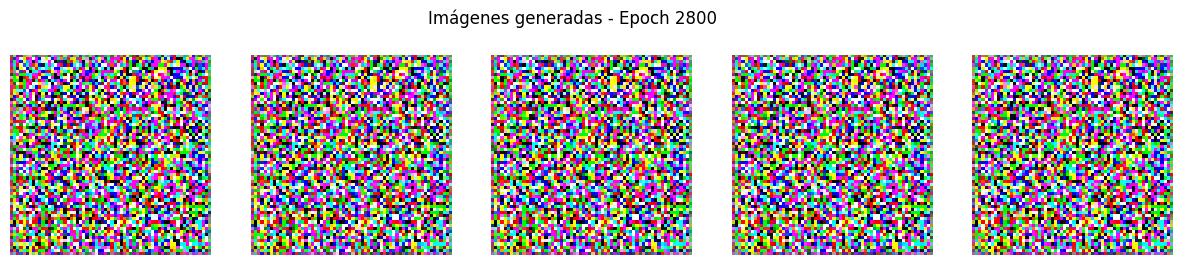

2801 [D loss: 2.6917, acc: 26.71%] [G loss: 0.0306]
2802 [D loss: 2.6919, acc: 26.71%] [G loss: 0.0306]
2803 [D loss: 2.6922, acc: 26.71%] [G loss: 0.0306]
2804 [D loss: 2.6924, acc: 26.71%] [G loss: 0.0305]
2805 [D loss: 2.6926, acc: 26.71%] [G loss: 0.0305]
2806 [D loss: 2.6929, acc: 26.71%] [G loss: 0.0305]
2807 [D loss: 2.6931, acc: 26.71%] [G loss: 0.0305]
2808 [D loss: 2.6933, acc: 26.72%] [G loss: 0.0305]
2809 [D loss: 2.6936, acc: 26.72%] [G loss: 0.0305]
2810 [D loss: 2.6938, acc: 26.72%] [G loss: 0.0305]
2811 [D loss: 2.6940, acc: 26.72%] [G loss: 0.0305]
2812 [D loss: 2.6943, acc: 26.72%] [G loss: 0.0305]
2813 [D loss: 2.6945, acc: 26.72%] [G loss: 0.0305]
2814 [D loss: 2.6948, acc: 26.72%] [G loss: 0.0304]
2815 [D loss: 2.6948, acc: 26.72%] [G loss: 0.0304]
2816 [D loss: 2.6950, acc: 26.71%] [G loss: 0.0304]
2817 [D loss: 2.6952, acc: 26.71%] [G loss: 0.0304]
2818 [D loss: 2.6955, acc: 26.71%] [G loss: 0.0304]
2819 [D loss: 2.6957, acc: 26.72%] [G loss: 0.0304]
2820 [D loss

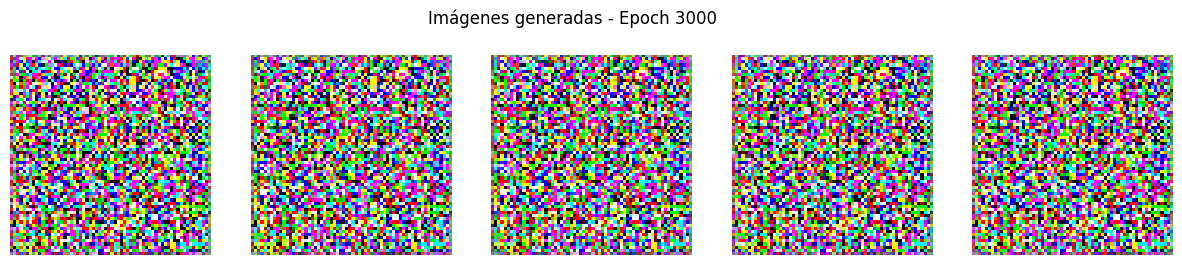

3001 [D loss: 2.7351, acc: 26.71%] [G loss: 0.0287]
3002 [D loss: 2.7353, acc: 26.71%] [G loss: 0.0287]
3003 [D loss: 2.7355, acc: 26.71%] [G loss: 0.0287]
3004 [D loss: 2.7358, acc: 26.71%] [G loss: 0.0287]
3005 [D loss: 2.7360, acc: 26.71%] [G loss: 0.0287]
3006 [D loss: 2.7362, acc: 26.71%] [G loss: 0.0287]
3007 [D loss: 2.7362, acc: 26.71%] [G loss: 0.0287]
3008 [D loss: 2.7364, acc: 26.71%] [G loss: 0.0286]
3009 [D loss: 2.7366, acc: 26.71%] [G loss: 0.0286]
3010 [D loss: 2.7369, acc: 26.71%] [G loss: 0.0286]
3011 [D loss: 2.7371, acc: 26.71%] [G loss: 0.0286]
3012 [D loss: 2.7373, acc: 26.71%] [G loss: 0.0286]
3013 [D loss: 2.7375, acc: 26.71%] [G loss: 0.0286]
3014 [D loss: 2.7377, acc: 26.71%] [G loss: 0.0286]
3015 [D loss: 2.7379, acc: 26.71%] [G loss: 0.0286]
3016 [D loss: 2.7381, acc: 26.71%] [G loss: 0.0286]
3017 [D loss: 2.7384, acc: 26.71%] [G loss: 0.0286]
3018 [D loss: 2.7386, acc: 26.71%] [G loss: 0.0286]
3019 [D loss: 2.7388, acc: 26.71%] [G loss: 0.0286]
3020 [D loss

KeyboardInterrupt: 

In [ ]:
# Entrenamiento
def train_gan(generator, discriminator, gan, dataset, epochs=1000, batch_size=32, save_interval=100): #Define la función para entrenar una GAN.
    for epoch in range(epochs): #Itera sobre cada época de entrenamiento.
        real_imgs = next(dataset) #Obtiene un nuevo lote de imágenes reales desde el generador de datos
        real_batch_size = real_imgs.shape[0] #Guarda el tamaño real del lote.

        noise = np.random.normal(0, 1, (real_batch_size, latent_dim)) #Genera un lote de vectores de ruido aleatorios para crear imágenes falsas.
        fake_imgs = generator.predict(noise, verbose=0) #Usa el generador para producir imágenes falsas a partir del ruido.

        d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((real_batch_size, 1))) #Entrena al discriminador con imágenes reales, etiquetadas como 1 (reales).
        d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((real_batch_size, 1))) #Entrena al discriminador con imágenes falsas, etiquetadas como 0 (falsas).
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake) #Calcula la pérdida promedio del discriminador (real + falsa).

        noise = np.random.normal(0, 1, (batch_size, latent_dim)) #Genera un nuevo lote de ruido para entrenar al generador.

        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1))) #Entrena la GAN (solo el generador) tratando de engañar al discriminador.

        print(f"{epoch} [D loss: {d_loss[0]:.4f}, acc: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]") #Imprime la pérdida y precisión del discriminador, y la pérdida del generador en cada epoch.

        #Cada save_interval epochs, genera y muestra imágenes para ver el progreso del generador.
        if epoch % save_interval == 0:
            generate_and_save_images(generator, epoch)

# Ejecutar entrenamiento
train_gan(generator, discriminator, gan, dataset, epochs=5000, batch_size=32, save_interval=200) #Entrenar la GAN durante 5000 épocas. Guarda una muestra de imágenes generadas cada 200 épocas.

In [ ]:
generator.save("generator_model.h5")

from google.colab import files
files.download("generator_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>